# Baseline Forecasting — One-Week-Ahead Dengue Cases

This notebook establishes simple forecasting benchmarks for weekly dengue case counts in **Maynas, Loreto, Peru**.

## Active forecasting scope

- **Target:** weekly `dengue_cases`
- **Forecast horizon:** one week ahead
- **Target week:** week \(t\)
- **Predictor availability:** information available through week \(t-1\)
- **Weekly convention:** Sunday–Saturday, identified by Sunday `week_start_date`
- **Final test period:** 2021–2023, held back from model selection

The purpose of this notebook is to answer a basic question before introducing climate-enhanced machine-learning models:

> How well can future dengue incidence already be predicted from recent dengue history and seasonality?

Two baseline specifications are evaluated on the **2018–2020 validation period only**:

1. **Persistence baseline** — predict next week's dengue cases using the most recently observed week's cases.
2. **Autoregressive + seasonality baseline** — use recent dengue lags plus cyclical annual seasonality in a simple Ridge regression.

The final 2021–2023 test period is not used for model selection or performance reporting in this notebook.

## 1. Setup and data loading

The engineered feature dataset was independently audited before modelling. This notebook reads:

`data/processed/modelling/maynas_dengue_features_1w_ahead.csv`

All exported outputs use repository-relative paths only.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd().resolve().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "modelling"
    / "maynas_dengue_features_1w_ahead.csv"
)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modelling"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_FILE)

df["week_start_date"] = pd.to_datetime(
    df["week_start_date"],
    errors="raise"
)

df = (
    df
    .sort_values("week_start_date")
    .reset_index(drop=True)
)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"First target week: {df['week_start_date'].min().date()}")
print(f"Last target week:  {df['week_start_date'].max().date()}")

Rows: 1,248
Columns: 73
First target week: 2000-01-02
Last target week:  2023-12-24


## 2. Freeze the chronological evaluation design

The chosen split is:

- **Training:** 2000–2017
- **Validation:** 2018–2020
- **Final test:** 2021–2023

The test period is deliberately excluded from all model-development metrics below.

In [2]:
TRAIN_END = pd.Timestamp("2017-12-31")
VALIDATION_START = pd.Timestamp("2018-01-01")
VALIDATION_END = pd.Timestamp("2020-12-31")
TEST_START = pd.Timestamp("2021-01-01")
TEST_END = pd.Timestamp("2023-12-31")

train_df = df.loc[
    df["week_start_date"] <= TRAIN_END
].copy()

validation_df = df.loc[
    (df["week_start_date"] >= VALIDATION_START)
    & (df["week_start_date"] <= VALIDATION_END)
].copy()

test_df = df.loc[
    (df["week_start_date"] >= TEST_START)
    & (df["week_start_date"] <= TEST_END)
].copy()

split_summary = pd.DataFrame({
    "period": ["train", "validation", "test"],
    "rows": [len(train_df), len(validation_df), len(test_df)],
    "first_week": [
        train_df["week_start_date"].min(),
        validation_df["week_start_date"].min(),
        test_df["week_start_date"].min(),
    ],
    "last_week": [
        train_df["week_start_date"].max(),
        validation_df["week_start_date"].max(),
        test_df["week_start_date"].max(),
    ],
})

split_summary

,period,rows,first_week,last_week
0,train,936,2000-01-02,2017-12-31
1,validation,156,2018-01-07,2020-12-27
2,test,156,2021-01-03,2023-12-24


In [3]:
assert train_df["week_start_date"].max() < validation_df["week_start_date"].min()
assert validation_df["week_start_date"].max() < test_df["week_start_date"].min()

print("Chronological split confirmed.")
print("Final test period is reserved and will not be scored in this notebook.")

Chronological split confirmed.
Final test period is reserved and will not be scored in this notebook.


## 3. Evaluation metrics

The main metrics are:

- **MAE** — primary metric; easier to interpret as the typical absolute weekly error.
- **RMSE** — secondary metric; penalises large misses more heavily, which matters because the dengue target contains major epidemic peaks.
- **R²** — supplementary descriptive metric for the regression baseline.

No metric from the 2021–2023 test period is calculated here.

In [4]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

## 4. Baseline 1 — persistence forecast

For one-week-ahead forecasting, the simplest credible benchmark is:

\[
\hat{y}_t = y_{t-1}
\]

In other words, next week's predicted dengue count equals the most recently observed week's count.

Because the feature-engineering pipeline preserved true calendar-week lags, `dengue_cases_lag1` is used rather than shifting rows directly.

In [5]:
persistence_validation = validation_df[
    [
        "week_start_date",
        "dengue_cases",
        "dengue_cases_lag1",
    ]
].dropna().copy()

persistence_validation["prediction"] = (
    persistence_validation["dengue_cases_lag1"]
)

persistence_metrics = regression_metrics(
    persistence_validation["dengue_cases"],
    persistence_validation["prediction"],
)

pd.Series(
    persistence_metrics,
    name="Persistence baseline"
)

MAE     11.205128
RMSE    26.616218
R2       0.860447
Name: Persistence baseline, dtype: float64

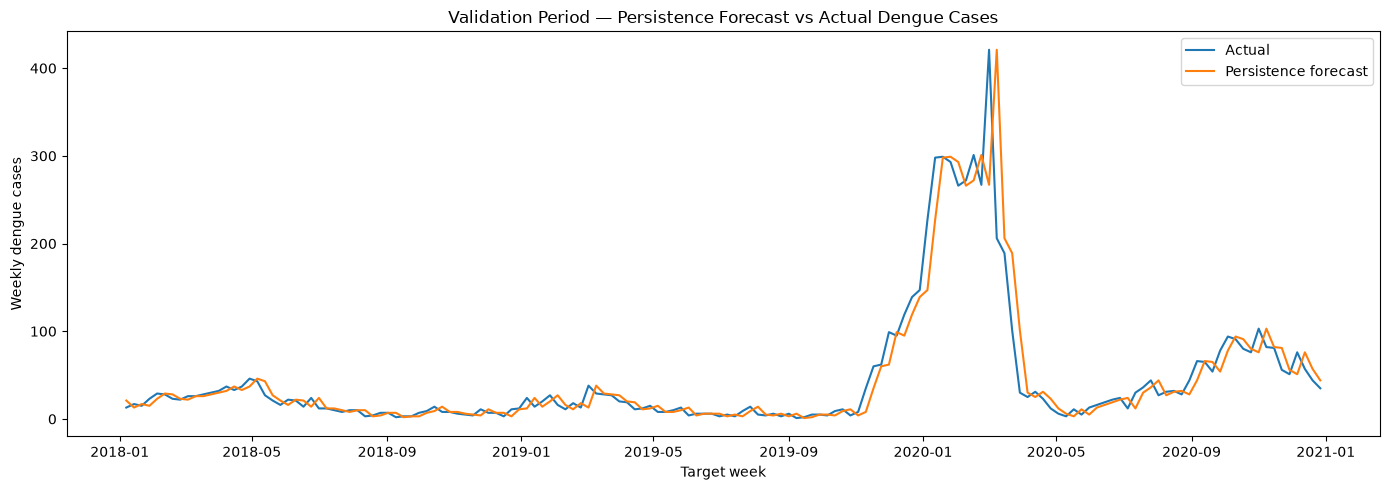

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    persistence_validation["week_start_date"],
    persistence_validation["dengue_cases"],
    label="Actual"
)

ax.plot(
    persistence_validation["week_start_date"],
    persistence_validation["prediction"],
    label="Persistence forecast"
)

ax.set_title("Validation Period — Persistence Forecast vs Actual Dengue Cases")
ax.set_xlabel("Target week")
ax.set_ylabel("Weekly dengue cases")
ax.legend()

plt.tight_layout()
plt.show()

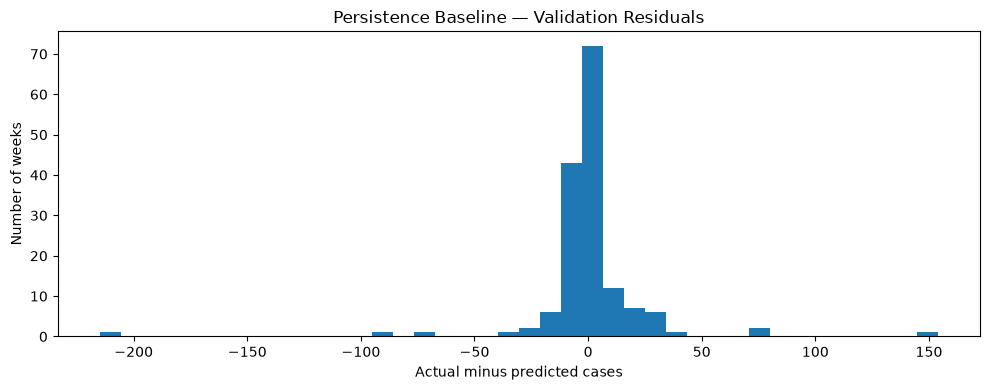

In [7]:
persistence_validation["residual"] = (
    persistence_validation["dengue_cases"]
    - persistence_validation["prediction"]
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    persistence_validation["residual"],
    bins=40
)

ax.set_title("Persistence Baseline — Validation Residuals")
ax.set_xlabel("Actual minus predicted cases")
ax.set_ylabel("Number of weeks")

plt.tight_layout()
plt.show()

### Interpretation — persistence baseline

This benchmark measures how much predictive value is obtained simply from the strong week-to-week persistence already observed during EDA.

Any more complex model should be judged against this baseline. A climate-enhanced model that cannot materially improve on persistence would provide limited evidence that the additional environmental data improves one-week-ahead forecasting.

## 5. Baseline 2 — dengue history + seasonality

The second baseline adds recent dengue history and annual seasonality while deliberately excluding all climate and environmental variables.

### Predictor set

- `week_sin`
- `week_cos`
- `dengue_cases_lag1`
- `dengue_cases_lag2`
- `dengue_cases_lag4`
- `dengue_cases_lag8`

A **Ridge regression** is used as a simple, transparent autoregressive regression benchmark. Standardisation is fitted on the training period only.

In [8]:
HISTORY_FEATURES = [
    "week_sin",
    "week_cos",
    "dengue_cases_lag1",
    "dengue_cases_lag2",
    "dengue_cases_lag4",
    "dengue_cases_lag8",
]

missing_history_features = [
    feature
    for feature in HISTORY_FEATURES
    if feature not in df.columns
]

if missing_history_features:
    raise ValueError(
        "Missing baseline feature(s): "
        + ", ".join(missing_history_features)
    )

HISTORY_FEATURES

['week_sin',
 'week_cos',
 'dengue_cases_lag1',
 'dengue_cases_lag2',
 'dengue_cases_lag4',
 'dengue_cases_lag8']

In [9]:
train_history = train_df[
    ["week_start_date", "dengue_cases"] + HISTORY_FEATURES
].dropna().copy()

validation_history = validation_df[
    ["week_start_date", "dengue_cases"] + HISTORY_FEATURES
].dropna().copy()

print(f"Training rows used:   {len(train_history):,}")
print(f"Validation rows used: {len(validation_history):,}")

Training rows used:   918
Validation rows used: 156


In [10]:
history_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0)),
    ]
)

history_model.fit(
    train_history[HISTORY_FEATURES],
    train_history["dengue_cases"],
)

validation_history["prediction_raw"] = history_model.predict(
    validation_history[HISTORY_FEATURES]
)

# Dengue case counts cannot be negative.
# Clipping is applied only to the output scale, not to the target during fitting.
validation_history["prediction"] = np.clip(
    validation_history["prediction_raw"],
    a_min=0,
    a_max=None,
)

history_metrics = regression_metrics(
    validation_history["dengue_cases"],
    validation_history["prediction"],
)

pd.Series(
    history_metrics,
    name="History + seasonality baseline"
)

MAE     13.168350
RMSE    25.328875
R2       0.873620
Name: History + seasonality baseline, dtype: float64

### Check whether clipping affects the baseline

A linear model can produce negative predictions even though dengue counts cannot be negative. The following check documents whether this occurs.

In [11]:
negative_predictions = int(
    (validation_history["prediction_raw"] < 0).sum()
)

print(
    f"Negative raw validation predictions clipped to zero: "
    f"{negative_predictions:,}"
)

Negative raw validation predictions clipped to zero: 1


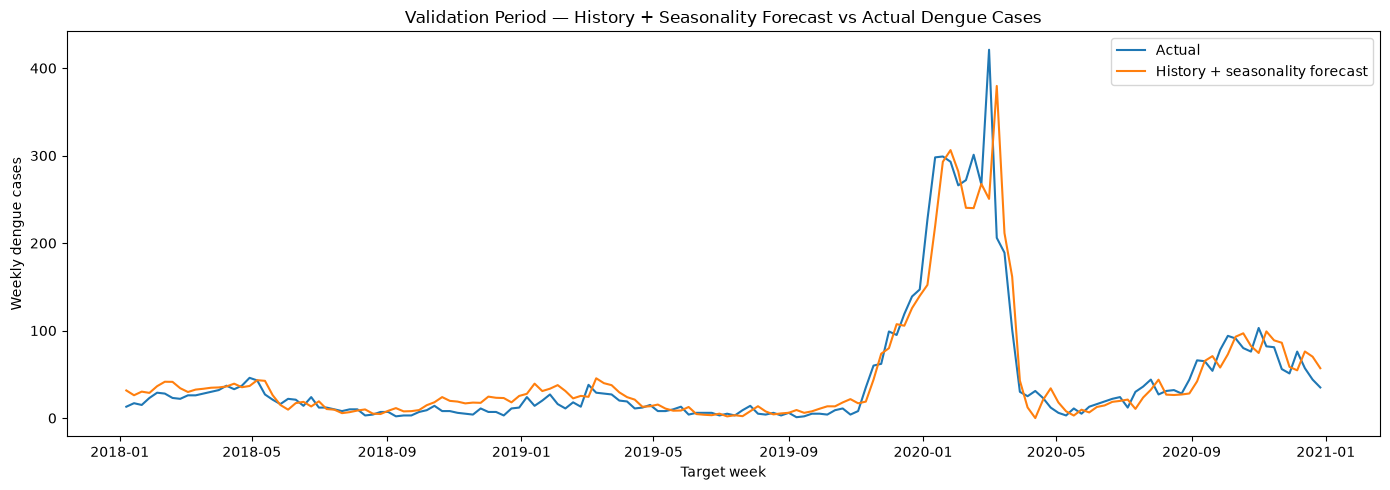

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    validation_history["week_start_date"],
    validation_history["dengue_cases"],
    label="Actual"
)

ax.plot(
    validation_history["week_start_date"],
    validation_history["prediction"],
    label="History + seasonality forecast"
)

ax.set_title(
    "Validation Period — History + Seasonality Forecast vs Actual Dengue Cases"
)
ax.set_xlabel("Target week")
ax.set_ylabel("Weekly dengue cases")
ax.legend()

plt.tight_layout()
plt.show()

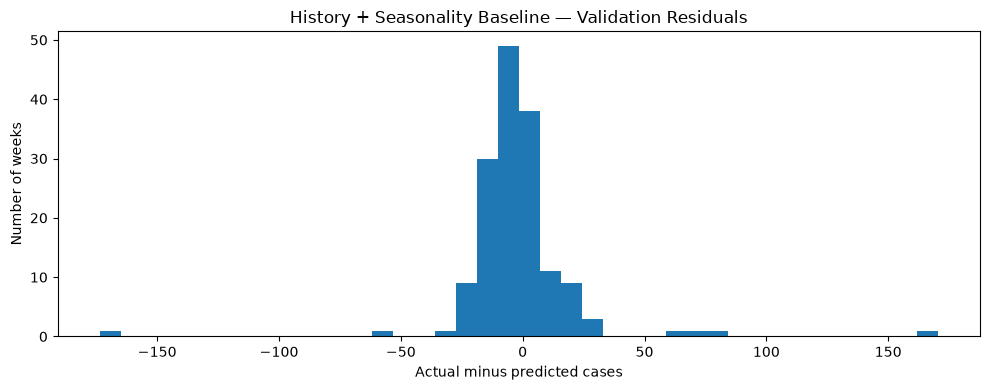

In [13]:
validation_history["residual"] = (
    validation_history["dengue_cases"]
    - validation_history["prediction"]
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    validation_history["residual"],
    bins=40
)

ax.set_title("History + Seasonality Baseline — Validation Residuals")
ax.set_xlabel("Actual minus predicted cases")
ax.set_ylabel("Number of weeks")

plt.tight_layout()
plt.show()

## 6. Direct baseline comparison

The comparison below uses the validation period only.

In [14]:
comparison = pd.DataFrame([
    {
        "model": "Persistence",
        **persistence_metrics,
        "validation_rows": len(persistence_validation),
    },
    {
        "model": "History + seasonality Ridge",
        **history_metrics,
        "validation_rows": len(validation_history),
    },
])

comparison

,model,MAE,RMSE,R2,validation_rows
0,Persistence,11.205128,26.616218,0.860447,156
1,History + seasonality Ridge,13.168350,25.328875,0.873620,156


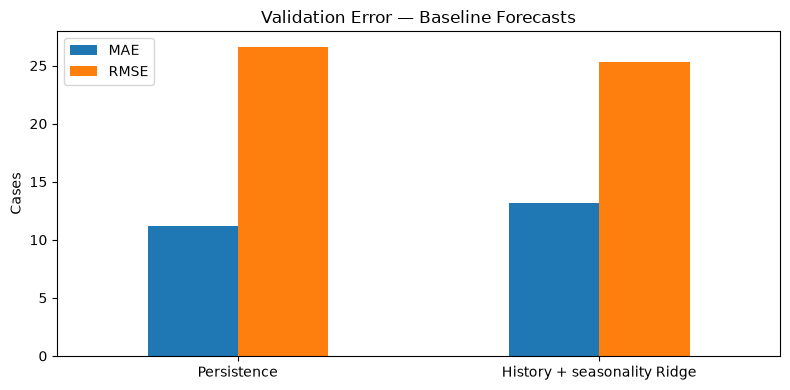

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

plot_df = comparison.set_index("model")[["MAE", "RMSE"]]

plot_df.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Validation Error — Baseline Forecasts")
ax.set_xlabel("")
ax.set_ylabel("Cases")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 7. Error behaviour during higher-incidence weeks

Because the target is strongly right-skewed, overall MAE and RMSE should be supplemented with a descriptive check of performance during higher-incidence validation weeks.

The full-series 95th percentile used previously for descriptive split analysis was approximately 179 cases. This threshold is used here only to examine error behaviour; it does **not** create a classification target.

In [16]:
HIGH_INCIDENCE_THRESHOLD = 179.30

def incidence_error_summary(prediction_df, model_name):
    temp = prediction_df.copy()
    temp["absolute_error"] = (
        temp["dengue_cases"] - temp["prediction"]
    ).abs()

    temp["incidence_group"] = np.where(
        temp["dengue_cases"] >= HIGH_INCIDENCE_THRESHOLD,
        "Higher-incidence weeks",
        "Other weeks",
    )

    result = (
        temp
        .groupby("incidence_group", as_index=False)
        .agg(
            weeks=("dengue_cases", "size"),
            mean_actual_cases=("dengue_cases", "mean"),
            MAE=("absolute_error", "mean"),
        )
    )

    result["model"] = model_name
    return result

incidence_error_table = pd.concat(
    [
        incidence_error_summary(
            persistence_validation,
            "Persistence"
        ),
        incidence_error_summary(
            validation_history,
            "History + seasonality Ridge"
        ),
    ],
    ignore_index=True,
)

incidence_error_table[
    [
        "model",
        "incidence_group",
        "weeks",
        "mean_actual_cases",
        "MAE",
    ]
]

,model,incidence_group,weeks,mean_actual_cases,MAE
0,Persistence,Higher-incidence weeks,11,276.272727,58.181818
1,Persistence,Other weeks,145,27.144828,7.641379
2,History + seasonality Ridge,Higher-incidence weeks,11,276.272727,58.955842
3,History + seasonality Ridge,Other weeks,145,27.144828,9.694816


## 8. Coefficients of the history + seasonality baseline

The Ridge coefficients provide a simple descriptive view of which historical terms the baseline uses most strongly after standardisation.

These coefficients are **not** interpreted causally.

In [17]:
ridge_model = history_model.named_steps["ridge"]

coefficient_table = pd.DataFrame({
    "feature": HISTORY_FEATURES,
    "standardised_coefficient": ridge_model.coef_,
})

coefficient_table["abs_coefficient"] = (
    coefficient_table["standardised_coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    "abs_coefficient",
    ascending=False,
)

coefficient_table

,feature,standardised_coefficient,abs_coefficient
2,dengue_cases_lag1,173.841929,173.841929
4,dengue_cases_lag4,-45.845808,45.845808
3,dengue_cases_lag2,38.058843,38.058843
1,week_cos,6.047357,6.047357
5,dengue_cases_lag8,4.655448,4.655448
0,week_sin,0.228854,0.228854


## 9. Save baseline development outputs

Only validation-development results are exported. The final test period remains unevaluated.

In [18]:
comparison.to_csv(
    OUTPUT_DIR / "baseline_validation_metrics.csv",
    index=False
)

incidence_error_table.to_csv(
    OUTPUT_DIR / "baseline_validation_incidence_errors.csv",
    index=False
)

coefficient_table.to_csv(
    OUTPUT_DIR / "baseline_history_coefficients.csv",
    index=False
)

persistence_validation[
    [
        "week_start_date",
        "dengue_cases",
        "prediction",
        "residual",
    ]
].to_csv(
    OUTPUT_DIR / "baseline_persistence_validation_predictions.csv",
    index=False
)

validation_history[
    [
        "week_start_date",
        "dengue_cases",
        "prediction",
        "residual",
    ]
].to_csv(
    OUTPUT_DIR / "baseline_history_validation_predictions.csv",
    index=False
)

print("Baseline development outputs saved to outputs/modelling/")

Baseline development outputs saved to outputs/modelling/


## 10. Interpretation and next modelling step

Use the completed validation results to answer:

1. How difficult is it to outperform a one-week persistence forecast?
2. Does adding multiple historical dengue lags and seasonality improve validation MAE and RMSE?
3. Where do the baseline models fail most severely — ordinary weeks or epidemic peaks?
4. Does the autoregressive model produce systematically biased or negative predictions?
5. What validation performance must climate-enhanced models beat?

### Next stage

The next modelling stage should retain the same chronological split and compare climate-enhanced models against these fixed baselines.

Recommended progression:

1. **Random Forest regression**
2. **XGBoost regression**
3. Compare against the baseline validation MAE/RMSE using the same 2018–2020 period
4. Select/tune models using validation only
5. Freeze all modelling decisions
6. Refit the selected final specifications using data available through 2020
7. Evaluate once on the untouched 2021–2023 final test period

The central hypothesis remains:

> Do climate and environmental variables improve one-week-ahead weekly dengue case prediction beyond recent dengue incidence and seasonality?